In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sotodlib import core
from fisher_sigma_r import *

In [18]:
def build_timeline(
    keep_LF=False, 
    extend_LF=None, 
    no_LF=False,
    scale_LF=None,
    add_n_tubes=[], 
    remove_n_tubes=[]
):
    ## year zero is 2025
    arr = np.array([ ## baseline full SO Schedule. Tubes for each year
        [0, 0, 0.5,  1, 0.5, 0, 0, 0, 0, 0, 0],  #f030 
        [0, 0, 0.5,  1, 0.5, 0, 0, 0, 0, 0, 0],  #f040 
        [1.33, 1.33, 2, 4, 4, 4, 4, 4, 4, 4, 4], #f090 
        [1.33, 1.33, 2, 4, 4, 4, 4, 4, 4, 4, 4], #f150 
        [ 0,   1,    1, 1, 1, 1, 1, 1, 1, 1, 1], #f220 
        [ 0,   1,    1, 1, 1, 1, 1, 1, 1, 1, 1], #f280
        [ 0,   0,    0, 0, 0, 0, 0, 0, 0, 0, 0], #f350
    ])
    if keep_LF:
        arr[0:2,4:] = 1
    elif extend_LF is not None:
        assert type(extend_LF) == int
        arr[0:2,4:4+extend_LF] = 1
        if extend_LF < 7:
            arr[0:2,4+extend_LF]=0.5
        if extend_LF >= 7:
            print("Should just use keep_LF")
    if no_LF:
        arr[0:2,:]=0
    if scale_LF is not None:
        arr[0:2,:]*=scale_LF
    for tube in add_n_tubes:
        for i in range(tube[0]):
            add_tube(arr, *tube[1:])
    for tube in remove_n_tubes:
        for i in range(tube[0]):
            remove_tube(arr, *tube[1:])
    return arr
        
def add_tube(timeline, flavor, year, weight=1):
    if flavor == 'LF':
        timeline[0:2, year:] += weight
    elif flavor =='MF':
        timeline[2:4, year:] += weight
    elif flavor == 'UHF':
        timeline[4:6, year:] += weight
    elif flavor == 'EHF':
        timeline[6, year:] += weight
    else:
        raise ValueError("invalid flavor, choose from LF, MF, UHF")

def remove_tube(timeline, flavor, year, weight=1):
    if flavor == 'LF':
        timeline[0:2, year:] -= weight
    elif flavor =='MF':
        timeline[2:4, year:] -= weight
    elif flavor == 'UHF':
        timeline[4:6, year:] -= weight
    elif flavor == 'EHF':
        timeline[6, year:] -= weight
    else:
        raise ValueError("invalid flavor, choose from LF, MF, UHF, EHF")
    if np.any(timeline) < 0:
        raise ValueError("tubes have gone down below zero!")

In [99]:
ol_vs_rl_factor = 91**2/50**2
experiment_configs = [
    ('SO Default', build_timeline()),
    ('SO add UFH 2029', build_timeline(add_n_tubes=[(1,"UHF",4, 1.0)])),
    ('SO add EFH-RL 2029', build_timeline(add_n_tubes=[(1,"EHF", 4, 1.0)])),
    ('SO add EFH-OL 2029', build_timeline(add_n_tubes=[(1,"EHF", 4, ol_vs_rl_factor)])),
    ('SO add UHF+EFH-OL 2029', build_timeline(add_n_tubes=[(1,"UHF",4, 1.0),(1,"EHF", 4, ol_vs_rl_factor)])),
    ('SO Keep LF', build_timeline(keep_LF=True)),
    ('SO+LF add UFH 2029', build_timeline(add_n_tubes=[(1,"UHF",4, 1.0)], keep_LF=True)),
    ('SO+LF add EFH-RL 2029', build_timeline(add_n_tubes=[(1,"EHF", 4, 1.0)], keep_LF=True)),
    ('SO+LF add EFH-OL 2029', build_timeline(add_n_tubes=[(1,"EHF", 4, ol_vs_rl_factor )], keep_LF=True)),
    ('SO+LF add UHF+EFH-OL 2029', build_timeline(add_n_tubes=[(1,"UHF",4, 1.0),(1,"EHF", 4, ol_vs_rl_factor)], keep_LF=True)),
]

In [101]:
configs = core.AxisManager(
    core.LabelAxis('bands', ['f030','f040','f090','f150','f220','f280', 'f350', 'planck30', 'planck44', 'planck353']),
    core.OffsetAxis('time_ax', 11),
    core.LabelAxis('exp_config', [x[0] for x in experiment_configs]),
    core.IndexAxis('Alens_ax', 2),
    core.IndexAxis('fsky_ax', 2),
    core.IndexAxis('foregrounds', 3),
)
configs.wrap('years', np.linspace(2025,2035,11), [(0,'time_ax')])
configs.wrap('times', configs.years-configs.years[0], [(0,'time_ax')])
##                                  f030  f040  f090  f150  f220  f280  f350  planck bands
configs.wrap('calc_depth',np.array([True, True, True, True, True, True, True,  False,  False, False]),[(0,'bands')])
configs.wrap('obs_rel',   np.array([1,    1,    1,    1,    0.65, 0.65, 0.5,  np.nan, np.nan, np.nan,]), [(0,'bands')])
configs.wrap('ell_knee',  np.array([50,   50,   50,   50,    50,   50,  50,   5,      5, 5,]), [(0,'bands')])
configs.wrap('ell_alpha', np.array([3.0,  2.7,  2.4,  2.6,  3.0,  3.2, 3.4,   3.0,    3.0, 3.0,]), [(0,'bands')])
configs.wrap('beam_fwhm', np.array([91.,  63.,  30.,  17.,  11.,  9.,   7,     32,     26, 4.92,]), [(0,'bands')])
configs.wrap('freqs',     np.array([27,   39,   93,   145,  225,  280,  346,  30,   44, 353,]), [(0,'bands')])

## baseline for LF and UHF
## goal for f090, 5uK rt.s for f150 because that's ~the best we've done 
## convert NETs to NEQ/Us with a sqrt(2)
configs.wrap('tube_NETs', np.array([21, 13, 3.4, 5.0, 8.6, 22, 91, np.nan, np.nan, np.nan])*np.sqrt(2), [(0,'bands')])

configs.wrap_new('n_tubes', ('exp_config', 'bands', 'time_ax'))
for i, x in enumerate(experiment_configs):
    configs.n_tubes[i,:-3] = x[1]

configs.wrap_new('tube_years', ('exp_config', 'bands', 'time_ax'))
configs.tube_years[:] = np.cumsum(configs.n_tubes, axis=-1)

configs.wrap('Alens', np.array([0.3, 0.5]), [(0,'Alens_ax')])
configs.wrap('fsky', np.array([0.06, 0.14]), [(0,'fsky_ax')])

if 'uK_arcmin' in configs:
    configs.move('uK_arcmin', None)
configs.wrap_new('uK_arcmin', ('exp_config', 'fsky_ax', 'bands', 'time_ax'))

configs.uK_arcmin[:,:,7,:] = 148 ## uK-arcmin Planck 30 (polarization map depths) 
configs.uK_arcmin[:,:,8,:] = 170 ## uK-arcmin Planck 44 (polarization map depths)
configs.uK_arcmin[:,:,9,:] = 7.31*60 ## uK-deg *60 Planck 353 (polarization map depths) from 2018 summary paper

configs.wrap_new('sigma_r', ('exp_config', 'Alens_ax', 'fsky_ax', 'time_ax'));

In [103]:
true_r=0
obs_eff=0.2
ell_min,ell_max= 30,300
ell = np.arange(ell_min, ell_max)

ell_cls, cl_r1_raw, cl_lens_raw = generate_theory_cls_with_camb()
cl_r1 = np.interp(ell, ell_cls, cl_r1_raw)
cl_lens = np.interp(ell, ell_cls, cl_lens_raw)

A = get_mixing_matrix([f for f in configs.freqs])
configs.wrap('mix_matrix', A, [(0,'bands'), (1,'foregrounds')])


AxisManager(years[time_ax], times[time_ax], calc_depth[bands], obs_rel[bands], ell_knee[bands], ell_alpha[bands], beam_fwhm[bands], freqs[bands], tube_NETs[bands], n_tubes[exp_config,bands,time_ax], tube_years[exp_config,bands,time_ax], Alens[Alens_ax], fsky[fsky_ax], uK_arcmin[exp_config,fsky_ax,bands,time_ax], sigma_r[exp_config,Alens_ax,fsky_ax,time_ax], mix_matrix[bands,foregrounds], bands:LabelAxis(10), time_ax:OffsetAxis(11), exp_config:LabelAxis(10), Alens_ax:IndexAxis(2), fsky_ax:IndexAxis(2), foregrounds:IndexAxis(3))

In [104]:
for exp in range(configs.exp_config.count):
    for f, fsky in enumerate(configs.fsky):
        for t in range(configs.time_ax.count):
            uK_arcmin = NET_to_uK_arcmin(
                NET_uKsqrtsec=configs.tube_NETs[configs.calc_depth], 
                N_det=configs.tube_years[exp,configs.calc_depth,t]*configs.obs_rel[configs.calc_depth], ## UHF doesn't work as well as  the others
                t_obs_years=1.0, ## years are wrapped into N_dets 
                fsky=fsky, 
                efficiency=obs_eff, ## 0.2 from forecasting paper
            )
            configs.uK_arcmin[exp, f,configs.calc_depth,t] = uK_arcmin

In [105]:
for exp in range(configs.exp_config.count):
    print(configs.exp_config.vals[exp], )
    for f, fsky in enumerate(configs.fsky):
        for t in range(configs.time_ax.count):  
            config = [{
                "freq": configs.freqs[i],  
                "N_white": configs.uK_arcmin[exp,f,i,t], 
                "alpha": configs.ell_alpha[i], 
                "ell_knee": configs.ell_knee[i], 
                "beam_fwhm":configs.beam_fwhm[i]} for i in range(configs.bands.count) 
            ]
            noise_dict = simulate_noise_spectra_multiband(ell, config)
            N_ell_eff = compute_effective_noise_multicomponent(ell, noise_dict, configs.mix_matrix, comp_index=0)
            for a, Alens in enumerate(configs.Alens):
                F, params = compute_fisher_matrix(ell, cl_r1, cl_lens, N_ell_eff, 
                          ell_min=ell_min, ell_max=ell_max, fsky=fsky, true_r=true_r,
                          include_alens=True, true_Al=Alens, extra_templates=None)
                configs.sigma_r[exp,a, f,t] = estimate_sigma_r(F, params)


SO Default
SO add UFH 2029
SO add EFH-RL 2029
SO add EFH-OL 2029
SO add UHF+EFH-OL 2029
SO Keep LF
SO+LF add UFH 2029
SO+LF add EFH-RL 2029
SO+LF add EFH-OL 2029
SO+LF add UHF+EFH-OL 2029


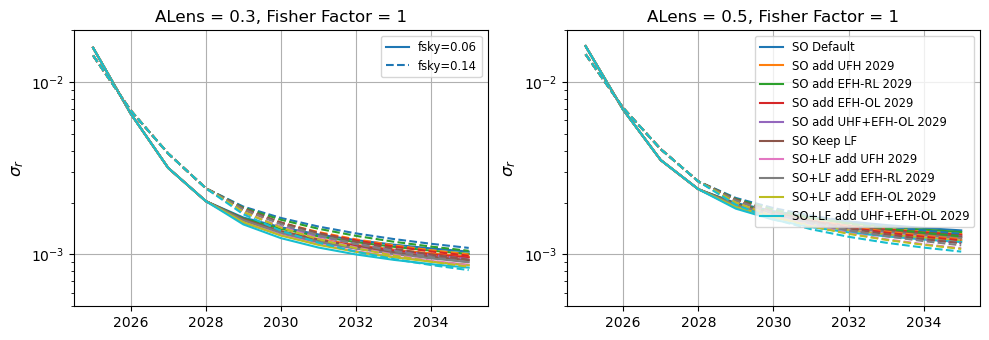

In [106]:
color = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
style = ['-', '--']
fisher_fac=1
tmsk = configs.years>2022

fig = plt.figure(figsize=(10,3.5))

for a in range(2):
    plt.subplot(1,2,a+1)
    for f in range(configs.fsky_ax.count):
        for exp in range(configs.exp_config.count):
            if a == 0 and exp==0:
                lab = f"fsky={configs.fsky[f]}"
            elif a==1 and f==0:
                lab = configs.exp_config.vals[exp]
            else:
                lab = None
            plt.plot(configs.years[tmsk], fisher_fac*configs.sigma_r[exp,a,f,tmsk], 
                     color=f'C{exp}', ls=style[f], label=lab)

    plt.legend(fontsize='small')
    plt.title(f"ALens = {configs.Alens[a]}, Fisher Factor = {fisher_fac}")
    #plt.xlim(2028,2035)
    
    plt.ylim(0.5e-3*fisher_fac, 20e-3*fisher_fac)
    plt.ylabel("$\\sigma_r$", size='large')
    plt.yscale('log')
    plt.grid()

fig.tight_layout()


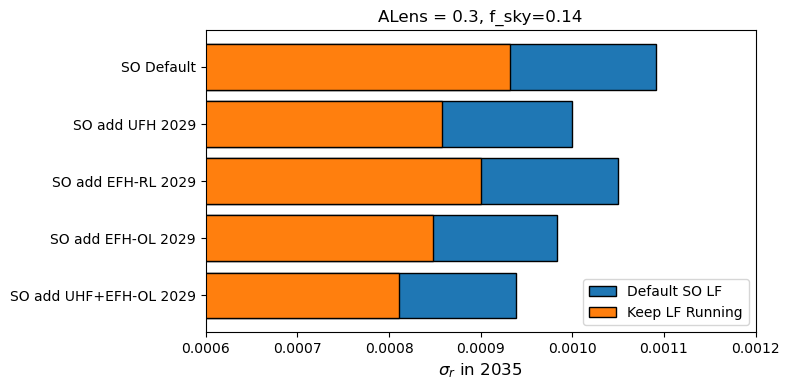

In [107]:
fig=plt.figure(figsize=(8,4))
a=0
f=1
plt.barh(configs.exp_config.vals[:5], configs.sigma_r[:5,a,f,-1], label='Default SO LF', ec='k' )
plt.barh(configs.exp_config.vals[:5], configs.sigma_r[5:,a,f,-1], label='Keep LF Running', ec='k' )

plt.title(f"ALens = {configs.Alens[a]}, f_sky={configs.fsky[f]}")
plt.legend()
plt.xlabel("$\\sigma_r$ in 2035", size='large')
plt.xlim(6e-4, 1.2e-3)
y0,y1=plt.ylim()
plt.ylim(y1,y0)
fig.tight_layout()
plt.savefig("20251109_EHF_options.png")

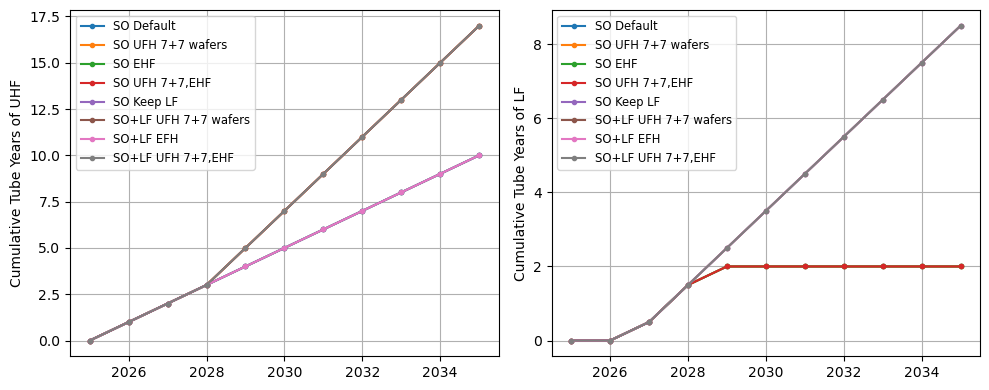

In [69]:
fig =plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
for exp in range(configs.exp_config.count):
    plt.plot( configs.years[tmsk], configs.tube_years[exp,5,:], '.-', label=configs.exp_config.vals[exp])
plt.legend(fontsize='small')
plt.ylabel("Cumulative Tube Years of UHF")
plt.grid()


plt.subplot(1,2,2)
for exp in range(configs.exp_config.count):
    plt.plot( configs.years[tmsk], configs.tube_years[exp,0,:], '.-', label=configs.exp_config.vals[exp])
plt.legend(fontsize='small')
plt.ylabel("Cumulative Tube Years of LF")
plt.grid()
fig.tight_layout()
